# Comparación: V-JEPA × V-JEPA2 × MC-JEPA × VideoMAE
## Con 3 estrategias EMA · estadísticas completas · cross-validation · 6 gráficas

---

## ¿Qué hace este notebook?

Este notebook implementa y compara **4 arquitecturas de aprendizaje auto-supervisado para video**,
cada una entrenada con **3 estrategias distintas de actualización EMA** del encoder teacher.
En total se ejecutan **12 experimentos** (4 modelos × 3 EMA), se registran métricas completas,
se realiza **cross-validation de 3 folds**, y se generan **6 figuras** de análisis.

Adicionalmente, en las secciones 15-17 se analiza por qué `GeneralizedEMA` supera a
`AdaptiveEMA` y se prueban **3 variantes mejoradas** de los hiperparámetros adaptativos.

---

## Contexto: aprendizaje auto-supervisado en video

En el paradigma **student-teacher self-supervised learning**, entrenamos un modelo (student)
para que sus representaciones internas sean similares a las de un segundo modelo (teacher)
que **no recibe gradientes directos** — su actualización ocurre suavemente a través del EMA.

El objetivo es que el student aprenda características útiles del video **sin necesitar etiquetas**,
forzándolo a predecir o reconstruir lo que el teacher (más estable, más promediado en el tiempo)
produce para la misma secuencia de frames.

---

## Los 4 modelos implementados

| Modelo | Estrategia | Input student | Input teacher | Loss |
|--------|-----------|---------------|---------------|------|
| **V-JEPA** | Predice todos los tokens | Video completo | Video completo | MSE sobre todos los N tokens |
| **V-JEPA2** | Predice solo posiciones enmascaradas (50%) | Video completo | Video completo | MSE sobre N×50% tokens |
| **MC-JEPA** | Multi-crop: student ve recorte local | Crop T/2 frames | Video completo | MSE (distinto T entre student/teacher) |
| **VideoMAE** | Reconstruye features de patches (75% máscara) | Video completo | Video completo | MSE sobre N×75% tokens |

---

## Las 3 estrategias EMA

| EMA | Fórmula de actualización | Parámetros clave |
|-----|--------------------------|-----------------|
| **Standard** | `θ_t ← τ·θ_t + (1-τ)·θ_s` | `τ=0.95` fijo |
| **Generalized** | `θ_t ← τ_base·θ_t + η·Δ + λ·v` donde `v` es momentum | `α, η, λ, τ_base` |
| **Adaptive** | Igual que Generalized pero `λ` escala dinámicamente con gate sigmoide | Más `k_gate, k_lam, gate_th, v_max` |

In [26]:
import os, copy, time
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset

try:
    from sklearn.model_selection import KFold
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print('sklearn no encontrado — instalar con: pip install scikit-learn')
    print('Cross-validation desactivado.')

## 1. CUDA + Timer

### ¿Por qué CUDA?

Las operaciones de convolución 3D sobre tensores de video son extremadamente costosas en CPU.
Con CUDA aprovechamos la GPU para paralelizar los cálculos matriciales, obteniendo típicamente
**10-50× de aceleración** sobre CPU para este tipo de modelos.

### Optimizaciones activadas

- **`cudnn.benchmark = True`**: cuDNN selecciona automáticamente el algoritmo de convolución
  más rápido para las dimensiones concretas de nuestros tensores. Hay un costo inicial de
  "warm-up" en las primeras iteraciones, pero luego el speedup es significativo.
- **`allow_tf32 = True`**: usa aritmética TF32 (19 bits de mantisa en lugar de 23) para
  operaciones matriciales y convoluciones. Pérdida de precisión mínima, ~2-3× más rápido.

### Funciones de utilidad

- `elapsed(t0)` sincroniza CUDA antes de medir para que el tiempo refleje trabajo real de GPU.
- `vram_peak_mb()` reporta el pico de memoria GPU usada, útil para saber si estamos cerca del límite.
- `reset_vram()` reinicia el contador de pico al inicio de cada epoch para mediciones limpias.

In [27]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {DEVICE}')
if DEVICE == 'cuda':
    print(f'  GPU:  {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

def elapsed(t0):
    if DEVICE == 'cuda': torch.cuda.synchronize()
    return time.perf_counter() - t0

def vram_peak_mb():
    if DEVICE != 'cuda': return 0.0
    return torch.cuda.max_memory_allocated() / 1e6

def reset_vram():
    if DEVICE == 'cuda': torch.cuda.reset_peak_memory_stats()

Dispositivo: cuda
  GPU:  NVIDIA GeForce RTX 3050 Ti Laptop GPU
  VRAM: 4.3 GB


## 2. Configuración

### Hiperparámetros globales

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `dim` | 256 | Dimensión del espacio de embedding. Suficientemente expresivo sin ser costoso para un encoder ligero. |
| `lr` | 1e-4 | Learning rate estándar para AdamW con modelos self-supervised. |
| `epochs` | 5 | Suficiente para observar convergencia relativa entre estrategias. |
| `batch_size` | 4/2 | Limitado por VRAM. Videos 3D son mucho más grandes que imágenes 2D. |
| `num_workers` | 4/0 | Workers paralelos para prefetch de datos desde disco/RAM. |
| `mask_ratio_vjepa2` | 0.50 | V-JEPA2 enmascara el 50% de los tokens — balance entre dificultad y señal. |
| `mask_ratio_videomae` | 0.75 | VideoMAE usa 75% de máscara — tarea más difícil que obliga al encoder a aprender más. |
| `cv_folds` | 3 | 3-fold cross-validation para estimación robusta del rendimiento. |

### ¿Por qué batch_size tan pequeño?

Un clip de video de forma `(B, T=16, C=3, H=112, W=112)` con B=4 ocupa aproximadamente:
`4 × 16 × 3 × 112 × 112 × 4 bytes ≈ 96 MB` solo en activaciones forward.
Con gradientes y el teacher duplicado, fácilmente superamos 2 GB por batch.


In [28]:
CONFIG = {
    'dim':        256,
    'lr':         1e-4,
    'epochs':     5,
    # Ajustar segun VRAM: 4GB->4, 8GB->8, 16GB->16
    'batch_size': 4 if DEVICE == 'cuda' else 2,
    'num_workers': 4 if DEVICE == 'cuda' else 0,
    # Mascaras
    'mask_ratio_vjepa2':   0.50,
    'mask_ratio_videomae': 0.75,
    # Cross-validation (poner cv_folds=0 para saltar)
    'cv_folds':  3,
    'cv_epochs': 3,
    'save_dir':  'resultados_comparacion',
}

save_dir = Path(CONFIG['save_dir'])
save_dir.mkdir(exist_ok=True)
print('Config:', CONFIG)

Config: {'dim': 256, 'lr': 0.0001, 'epochs': 5, 'batch_size': 4, 'num_workers': 4, 'mask_ratio_vjepa2': 0.5, 'mask_ratio_videomae': 0.75, 'cv_folds': 3, 'cv_epochs': 3, 'save_dir': 'resultados_comparacion'}


## 3. Carga de datos — InHARD

### ¿Qué es InHARD?

**InHARD** (Industrial Human Action Recognition Dataset) fue creado por LINEACT-CESI para
el reconocimiento de acciones humanas en entornos industriales de manufactura.
Contiene grabaciones de operadores ensamblando piezas, con anotaciones de:

- **Acciones de meta-nivel** (10 clases): como *Pick*, *Place*, *Screw*, etc.
- **Acciones específicas** (más de 30 sub-clases): variantes detalladas de cada meta-acción.
- **Datos multimodales**: video RGB + esqueleto BVH con 24 joints.

### Nuestro loader (`InHARDSegmented`)

El loader personalizado:
1. Lee segmentos pre-cortados del video (no frames sueltos).
2. Reescala cada clip a `T=16 frames × H=112 × W=112 píxeles`.
3. Opcionalmente pre-carga todo en RAM (`preload=True`) para evitar I/O durante el entrenamiento.
4. Retorna `(video_tensor, skeleton_tensor, label)` por muestra.

### `max_per_class`

Limitamos a 40 clips de entrenamiento y 10 de validación **por clase** para mantener
tiempos manejables y un dataset balanceado. En producción usaríamos todos los clips disponibles.

### `ds_to_tensors`

Convierte el dataset a tensores pre-cargados:
- `X`: video `(N, T, C, H, W)`
- `S`: esqueleto `(N, T, 72)` — 24 joints × 3 coordenadas (xyz), primeros 72 valores
- `y`: etiquetas `(N,)` como enteros


In [29]:
from inhard_loader import InHARDSegmented, INHARD_CLASSES

INHARD_ROOT = r'D:\iNHARD\01-InHARD\Segmented'
T, H, W = 16, 112, 112

t0 = time.perf_counter()
print('Cargando datos...')

train_ds = InHARDSegmented(INHARD_ROOT, 'train', T=T, H=H, W=W,
                           max_per_class=40, with_skeleton=True, preload=True)
val_ds   = InHARDSegmented(INHARD_ROOT, 'val',   T=T, H=H, W=W,
                           max_per_class=10, with_skeleton=True, preload=True)

print(f'Carga total: {elapsed(t0):.1f} s')

def ds_to_tensors(ds):
    X = torch.stack([item[0] for item in ds.preloaded])
    S = torch.stack([item[1] for item in ds.preloaded])
    y = torch.tensor([item[2] for item in ds.preloaded])
    return X, S[:, :, :72], y

X_train, S_train, y_train = ds_to_tensors(train_ds)
X_val,   S_val,   y_val   = ds_to_tensors(val_ds)

NUM_CLASSES = len(train_ds.classes)
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Clases: {NUM_CLASSES}')

Cargando datos...
  Train participants: ['P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P13', 'P02', 'P04', 'P01', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 

100%|██████████| 552/552 [11:56<00:00,  1.30s/it]


Pre-cargados: 552 / 552
  Train participants: ['P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P13', 'P02', 'P04', 'P01', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P10', 'P11', 'P12', 'P06', 'P07', 'P03', 'P05', 'P09', 'P08', 'P13', 'P02', 'P04', 'P01', 'P10', 'P11', 'P12', 'P06', '

100%|██████████| 135/135 [02:22<00:00,  1.06s/it]


Pre-cargados: 135 / 135
Carga total: 859.5 s
Train: torch.Size([552, 16, 3, 112, 112])  Val: torch.Size([135, 16, 3, 112, 112])  Clases: 14


## 4. DataLoaders

### Optimizaciones para GPU

| Parámetro | Efecto |
|-----------|--------|
| `pin_memory=True` | Reserva memoria RAM "anclada" (no paginable). PyTorch puede transferir datos CPU→GPU con DMA directo, sin copiar primero a un buffer intermedio. ~20% más rápido en transferencias. |
| `non_blocking=True` | (en `.to(DEVICE)`) La transferencia ocurre en un stream CUDA separado, solapando transferencia con cómputo. |
| `persistent_workers=True` | Los procesos worker de DataLoader permanecen vivos entre epochs. Evita el costo de crear/destruir procesos en cada epoch (~0.5-2s por epoch). |
| `num_workers=4` | 4 procesos paralelos leen y preparan batches mientras la GPU trabaja con el batch actual. |

### `make_loader`

Función auxiliar que reutilizamos también en la cross-validation para crear loaders
de train y validación con los mismos hiperparámetros de eficiencia.


In [30]:
PIN = (DEVICE == 'cuda')
PW  = (CONFIG['num_workers'] > 0)

train_dataset = TensorDataset(X_train, S_train, y_train)
val_dataset   = TensorDataset(X_val,   S_val,   y_val)

def make_loader(ds, shuffle):
    return DataLoader(ds,
        batch_size=CONFIG['batch_size'], shuffle=shuffle,
        num_workers=CONFIG['num_workers'], pin_memory=PIN,
        persistent_workers=PW)

train_loader = make_loader(train_dataset, shuffle=True)
val_loader   = make_loader(val_dataset,   shuffle=False)

print(f'train batches: {len(train_loader)}  val batches: {len(val_loader)}')

train batches: 138  val batches: 34


## 5. Componentes compartidos

### `BaseEncoder` — el corazón de todos los modelos

Es un encoder **Conv3D ligero** que convierte un clip de video en una secuencia de tokens
de características, siguiendo el paradigma de Vision Transformers pero con convoluciones.

**Flujo de datos:**
```
(B, T, C, H, W)          # Entrada: batch de clips
    ↓  permute
(B, C, T, H, W)          # Conv3D espera (batch, canales, tiempo, alto, ancho)
    ↓  Conv3D(3→64) + GELU + GroupNorm
    ↓  Conv3D(64→256) + GELU
    ↓  AdaptiveAvgPool3D → (B, 256, 4, 4, 4)
    ↓  reshape + permute
(B, N=64, D=256)          # Salida: 64 tokens de 256 dimensiones cada uno
```

**¿Por qué GroupNorm en lugar de BatchNorm?**
Con batch_size=4, BatchNorm tiene estadísticas poco representativas (4 muestras no es suficiente).
GroupNorm normaliza por grupos de canales dentro de cada muestra — funciona bien con batches pequeños.

**¿Por qué AdaptiveAvgPool3D → (4,4,4)?**
Fija el número de tokens de salida (4×4×4 = 64) independientemente del tamaño de entrada.
Esto permite que el mismo encoder procese videos de distintas duraciones/resoluciones.

### `BasePredictor`

Red MLP de 2 capas que mapea tokens del student → espacio predicho del teacher.
Permite que el student aprenda a "predecir" las representaciones del teacher incluso
cuando sus espacios internos no están perfectamente alineados.

### `random_mask` y `gather_mask`

Utilidades para seleccionar tokens enmascarados:
- `random_mask`: genera índices aleatorios (sin reemplazo) de tokens a enmascarar.
- `gather_mask`: extrae los tokens en esas posiciones del tensor de forma eficiente.

### `freeze` y `make_teacher`

El teacher es una **copia congelada** del student al inicio. Sus pesos se actualizan
exclusivamente vía EMA, nunca por backpropagation. Esto garantiza que el teacher sea
siempre una versión más "suavizada" y estable del student.


In [31]:
class BaseEncoder(nn.Module):
    """Encoder Conv3D ligero: (B,T,C,H,W) -> (B,N,D) tokens."""
    def __init__(self, dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(3, 64, 3, padding=1), nn.GELU(),
            nn.GroupNorm(8, 64),
            nn.Conv3d(64, dim, 3, padding=1), nn.GELU(),
        )
        self.pool = nn.AdaptiveAvgPool3d((4, 4, 4))

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)   # (B,T,C,H,W) -> (B,C,T,H,W)
        x = self.net(x)
        x = self.pool(x)
        B, D, t, h, w = x.shape
        return x.reshape(B, D, -1).permute(0, 2, 1)  # (B, N, D)


class BasePredictor(nn.Module):
    def __init__(self, dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.GELU(), nn.Linear(dim, dim)
        )
    def forward(self, x): return self.net(x)


def freeze(module):
    for p in module.parameters(): p.requires_grad = False

def make_teacher(encoder):
    t = copy.deepcopy(encoder)
    freeze(t)
    return t

def gather_mask(tensor, mask_ids):
    D = tensor.shape[-1]
    return tensor.gather(1, mask_ids.unsqueeze(-1).expand(-1, -1, D))

def random_mask(B, N, ratio, device):
    num_masked = max(1, int(N * ratio))
    noise = torch.rand(B, N, device=device)
    ids   = torch.argsort(noise, dim=1)
    return ids[:, :num_masked]

print('Componentes base listos.')

Componentes base listos.


## 6. Modelos

Todos los modelos comparten la misma interfaz:
- `model.student` — encoder entrenable (recibe gradientes)
- `model.teacher` — encoder EMA (congelado, actualizado por EMA)
- `model(video)` → `(pred, target)` listos para `F.mse_loss(pred, target)`

---

### V-JEPA (Video Joint Embedding Predictive Architecture)

**Referencia**: LeCun & Assran et al., Meta AI 2024.

**Idea central**: El student procesa el video completo y predice las representaciones del teacher
para **todos los tokens**. No hay enmascaramiento — es una destilación de conocimiento suave.

```
video → student → predictor → pred (B, N, D)
video → teacher (no grad) → target (B, N, D)
loss = MSE(pred, target)  ←  sobre los N=64 tokens completos
```

**¿Qué aprende?** La representación del student converge hacia la del teacher (más estable),
aprendiendo features temporalmente coherentes del video.

---

### V-JEPA2

**Variante con enmascaramiento del 50% de tokens.**

El student procesa el video completo pero **solo predice las posiciones enmascaradas**.
Esto crea una tarea más difícil: el modelo debe inferir representaciones en posiciones
que no "vio" directamente en el espacio del teacher.

```
video → student → predictor → pred_masked (B, N/2, D)
video → teacher → target_all → target_masked (B, N/2, D)
loss = MSE sobre solo los N×50% tokens enmascarados
```

**Ventaja vs V-JEPA**: La máscara actúa como regularización implícita, forzando al modelo
a construir representaciones más holísticas del video.

---

### MC-JEPA (Multi-Crop JEPA)

**Inspirado en**: DINO, iBOT (Caron et al. 2021).

**Idea**: El student solo ve un **recorte temporal local** (T/2 frames aleatoriamente ubicados),
mientras el teacher ve el video **completo**. El student debe predecir la representación global
a partir de información local.

```
local_crop (T/2 frames) → student → predictor → pred (B, N_local, D)
video completo          → teacher              → target (B, N, D)
loss = MSE(pred, target)  ←  a pesar de distintos T
```

**¿Qué aprende?** Invarianza temporal: el modelo aprende que distintas ventanas temporales
del mismo video deben tener representaciones compatibles. Esto fomenta features de alto nivel.

---

### VideoMAE (Masked Autoencoder para Video)

**Referencia**: Tong et al. 2022 (adaptado al paradigma student-teacher).

**Idea**: Enmascara el 75% de patches del video. El encoder procesa **todo** el video
(incluyendo los enmascarados), luego un decoder ligero reconstruye las features del teacher
en las posiciones enmascaradas.

```
video → student (encoder) → decoder → pred_masked (B, N×0.75, D)
video → teacher           → target_all → target_masked (B, N×0.75, D)
loss = MSE sobre 75% de tokens
```

**¿Por qué 75%?** Con mayor ratio de máscara, el modelo no puede simplemente "copiar" tokens
vecinos — debe comprender la estructura espacio-temporal del video para reconstruir lo faltante.


In [32]:
# V-JEPA: predice TODOS los tokens del teacher (video completo)
class VJEPA(nn.Module):
    def __init__(self, dim=256, **_):
        super().__init__()
        self.student   = BaseEncoder(dim)
        self.teacher   = make_teacher(self.student)
        self.predictor = BasePredictor(dim)

    def forward(self, video):
        tokens_s = self.student(video)
        pred     = self.predictor(tokens_s)
        with torch.no_grad():
            target = self.teacher(video)
        return pred, target


# V-JEPA2: solo predice en posiciones enmascaradas (mask_ratio=50%)
class VJEPA2(nn.Module):
    def __init__(self, dim=256, mask_ratio=0.5, **_):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.student    = BaseEncoder(dim)
        self.teacher    = make_teacher(self.student)
        self.predictor  = BasePredictor(dim)

    def forward(self, video):
        all_s = self.student(video)
        with torch.no_grad():
            all_t = self.teacher(video)
        B, N, D  = all_s.shape
        mask_ids = random_mask(B, N, self.mask_ratio, video.device)
        pred   = gather_mask(self.predictor(all_s), mask_ids)
        target = gather_mask(all_t, mask_ids)
        return pred, target


# MC-JEPA: student en crop temporal local, teacher en video global
class MCJEPA(nn.Module):
    def __init__(self, dim=256, local_ratio=0.5, **_):
        super().__init__()
        self.local_ratio = local_ratio
        self.student     = BaseEncoder(dim)
        self.teacher     = make_teacher(self.student)
        self.predictor   = BasePredictor(dim)

    def forward(self, video):
        B, T, C, H, W = video.shape
        t_local  = max(1, int(T * self.local_ratio))
        t_start  = torch.randint(0, T - t_local + 1, (1,)).item()
        local    = video[:, t_start:t_start + t_local]
        tokens_s = self.student(local)
        pred     = self.predictor(tokens_s)
        with torch.no_grad():
            target = self.teacher(video)
        return pred, target


# VideoMAE: reconstruye features del teacher en patches enmascarados (75%)
class VideoMAE(nn.Module):
    def __init__(self, dim=256, mask_ratio=0.75, **_):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.student    = BaseEncoder(dim)
        self.teacher    = make_teacher(self.student)
        self.decoder    = nn.Sequential(
            nn.Linear(dim, dim // 2), nn.GELU(),
            nn.Linear(dim // 2, dim),
        )

    def forward(self, video):
        with torch.no_grad():
            target_all = self.teacher(video)
        B, N, D  = target_all.shape
        mask_ids = random_mask(B, N, self.mask_ratio, video.device)
        enc  = self.student(video)
        dec  = self.decoder(enc)
        pred   = gather_mask(dec,        mask_ids)
        target = gather_mask(target_all, mask_ids)
        return pred, target


print('4 modelos definidos: VJEPA, VJEPA2, MCJEPA, VideoMAE')

4 modelos definidos: VJEPA, VJEPA2, MCJEPA, VideoMAE


## 7. Estrategias EMA

El **Exponential Moving Average (EMA)** es el mecanismo que actualiza los pesos del teacher
a partir de los pesos del student de forma suave, sin backpropagation.

---

### StandardEMA — La versión clásica

**Fórmula:**
```
θ_teacher ← τ · θ_teacher + (1 - τ) · θ_student
```

Con `τ=0.95`, el teacher retiene el 95% de sus pesos anteriores y absorbe el 5% del student
por cada paso. Esto lo hace resistente a actualizaciones ruidosas del student, actuando como
un **ensemble temporal** implícito.

**Limitación**: `τ` es fijo. No adapta la velocidad de actualización según el estado del entrenamiento.

---

### GeneralizedEMA — EMA con momentum

**Fórmula:**
```
v ← α · v + (1 - α) · (θ_s - θ_t)     # acumula momentum del delta
θ_t ← τ_base · θ_t + η · Δ + λ · v    # actualización enriquecida
```

Introduce un **vector de velocidad `v`** (momentum) por parámetro que acumula el historial
de cambios recientes. Esto permite que el teacher:
1. Responda más rápido cuando el student mejora consistentemente (velocidad alta).
2. Sea más conservador cuando hay oscilaciones (velocidad se cancela).



---

### AdaptiveGeneralizedEMA — EMA con gate sigmoide

**Fórmula:**
```
gate    = σ(k_gate · (||v_i|| - gate_th))      # gate ∈ (0, 1)
λ_dyn   = min(λ · (1 + k_lam · gate), v_max)   # λ dinámico
θ_t ← τ_base · θ_t + η · Δ + λ_dyn · v        # igual que Generalized pero con λ variable
```

La **función gate** es una sigmoide centrada en `gate_th` que se activa cuando la norma del
momentum supera un umbral. Cuando el momentum es alto (student cambiando rápido), λ aumenta
para que el teacher "siga" más al student.

**Problema (analizado en Sección 15)**: con `k_gate=10` la sigmoide es casi binaria,
causando picos bruscos de λ al inicio del entrenamiento.

**Parámetros:**
- `alpha`: decaimiento del momentum de velocidad (0.15 = memoria corta)
- `eta`: peso del delta directo en la actualización
- `lam`: λ base para la componente de momentum
- `tau_base`: factor de retención base (análogo a τ en StandardEMA)
- `v_max`: límite superior de λ_dyn (evita que el gate escale λ de forma descontrolada)
- `k_gate`: pendiente de la sigmoide (10 = casi binaria, 3 = suave)
- `gate_th`: umbral de norma de velocidad que activa el gate


In [33]:
class StandardEMA:
    def __init__(self, tau=0.95):
        self.tau = tau
        self.last_vel_norm = 0.0

    @torch.no_grad()
    def update(self, student, teacher):
        for ps, pt in zip(student.parameters(), teacher.parameters()):
            pt.data.mul_(self.tau).add_((1 - self.tau) * ps.data)


class GeneralizedEMA:
    """EMA con momentum. velocity es lista[Tensor] por parametro (bug-free)."""
    def __init__(self, alpha=0.15, eta=0.05, lam=0.05, tau_base=0.95):
        self.alpha=alpha; self.eta=eta; self.lam=lam; self.tau_base=tau_base
        self.velocity = None
        self.last_vel_norm = 0.0

    @torch.no_grad()
    def update(self, student, teacher):
        pairs = list(zip(student.parameters(), teacher.parameters()))
        if self.velocity is None:
            self.velocity = [torch.zeros_like(pt) for _, pt in pairs]
        sq = []
        for i, (ps, pt) in enumerate(pairs):
            d = ps.data - pt.data
            self.velocity[i] = self.alpha * self.velocity[i] + (1 - self.alpha) * d
            pt.data.mul_(self.tau_base).add_(self.eta * d + self.lam * self.velocity[i])
            sq.append(self.velocity[i].norm().item()**2)
        self.last_vel_norm = sum(sq)**0.5


class AdaptiveGeneralizedEMA:
    """EMA con gate sigmoide sobre la norma de velocity."""
    def __init__(self, alpha=0.15, eta=0.05, lam=0.05, tau_base=0.95,
                 v_max=0.2, k_lam=5.0, k_gate=10.0, gate_th=0.005):
        self.alpha=alpha; self.eta=eta; self.lam=lam; self.tau_base=tau_base
        self.v_max=v_max; self.k_lam=k_lam; self.k_gate=k_gate; self.gate_th=gate_th
        self.velocity = None
        self.last_vel_norm = 0.0

    @torch.no_grad()
    def update(self, student, teacher):
        pairs = list(zip(student.parameters(), teacher.parameters()))
        if self.velocity is None:
            self.velocity = [torch.zeros_like(pt) for _, pt in pairs]
        sq = []
        for i, (ps, pt) in enumerate(pairs):
            d = ps.data - pt.data
            self.velocity[i] = self.alpha * self.velocity[i] + (1 - self.alpha) * d
            v_norm  = self.velocity[i].norm().item()
            gate    = torch.sigmoid(torch.tensor(self.k_gate * (v_norm - self.gate_th))).item()
            lam_dyn = min(self.lam * (1 + self.k_lam * gate), self.v_max)
            pt.data.mul_(self.tau_base).add_(self.eta * d + lam_dyn * self.velocity[i])
            sq.append(v_norm**2)
        self.last_vel_norm = sum(sq)**0.5

print('3 estrategias EMA listas.')

3 estrategias EMA listas.


## 8. Matrices de experimentos

Definimos los 4 modelos y 3 estrategias EMA como listas de tuplas `(nombre, clase, kwargs)`.
El producto cartesiano de ambas listas genera los 12 experimentos principales.

### ¿Por qué esta estructura?

Permite iterar sobre todos los experimentos con un doble `for` limpio, sin duplicar código.
Cada experimento recibe exactamente los mismos hiperparámetros del modelo y del EMA,
garantizando comparaciones justas.

### Hiperparámetros EMA compartidos

Todos los EMA usan `tau=0.95` (Standard) o `{alpha=0.15, eta=0.05, lam=0.05, tau_base=0.95}`
(Generalized/Adaptive). La única diferencia entre Generalized y Adaptive son los hiperparámetros
del gate sigmoide que se activan en AdaptiveGeneralizedEMA.


In [34]:
MODEL_CONFIGS = [
    ('V-JEPA',   VJEPA,    {'dim': CONFIG['dim']}),
    ('V-JEPA2',  VJEPA2,   {'dim': CONFIG['dim'], 'mask_ratio': CONFIG['mask_ratio_vjepa2']}),
    ('MC-JEPA',  MCJEPA,   {'dim': CONFIG['dim']}),
    ('VideoMAE', VideoMAE, {'dim': CONFIG['dim'], 'mask_ratio': CONFIG['mask_ratio_videomae']}),
]

EMA_CONFIGS = [
    ('Standard',    StandardEMA,            {'tau': 0.95}),
    ('Generalized', GeneralizedEMA,         {'alpha': 0.15, 'eta': 0.05, 'lam': 0.05, 'tau_base': 0.95}),
    ('Adaptive',    AdaptiveGeneralizedEMA, {'alpha': 0.15, 'eta': 0.05, 'lam': 0.05, 'tau_base': 0.95,
                                             'v_max': 0.2, 'k_lam': 5.0, 'k_gate': 10.0, 'gate_th': 0.005}),
]

MODEL_NAMES = [m for m, _, _ in MODEL_CONFIGS]
EMA_NAMES   = [e for e, _, _ in EMA_CONFIGS]
print(f'Experimentos principales: {len(MODEL_CONFIGS)} x {len(EMA_CONFIGS)} = {len(MODEL_CONFIGS)*len(EMA_CONFIGS)}')

Experimentos principales: 4 x 3 = 12


## 9. Tracker de estadísticas + funciones de entrenamiento

### `ExperimentTracker`

DataFrame-based logger que registra **10 métricas por epoch** por experimento:

| Métrica | Descripción |
|---------|-------------|
| `model` | Nombre del modelo (V-JEPA, etc.) |
| `ema` | Estrategia EMA usada |
| `fold` | Fold de CV (0 = experimento principal) |
| `epoch` | Número de epoch |
| `train_loss` / `train_mse` | MSE promedio sobre el conjunto de entrenamiento |
| `val_loss` / `val_mse` | MSE promedio sobre el conjunto de validación |
| `epoch_time_s` | Duración de la epoch en segundos |
| `throughput_sps` | Muestras procesadas por segundo |
| `vram_peak_mb` | Pico de memoria GPU en la epoch |
| `vel_norm` | Norma L2 del vector de velocidad EMA (solo Generalized/Adaptive) |

El método `summary()` agrupa por (modelo, EMA) y calcula media ± std de las métricas
de la **última epoch** de cada fold.

---

### `train_epoch` — Mixed Precision Training

Usa **Automatic Mixed Precision (AMP)** de PyTorch:
- `torch.amp.autocast`: ejecuta forward pass en FP16 donde es seguro, FP32 donde no lo es.
- `GradScaler`: escala los gradientes para evitar underflow en FP16, luego des-escala antes del `step`.
- Resultado: ~50% menos uso de VRAM y ~30-50% más velocidad en GPUs modernas.

`optimizer.zero_grad(set_to_none=True)` elimina los tensores de gradiente completamente
(en lugar de llenarlos con ceros), ahorrando un poco de VRAM y tiempo.

---

### `val_epoch`

Evaluación sin gradientes (`torch.no_grad()`), también con AMP.
No llama a `ema.update()` — el teacher no cambia durante validación.


In [35]:
class ExperimentTracker:
    def __init__(self):
        self.records = []

    def log(self, model, ema, fold, epoch,
            train_loss, val_loss, epoch_time, throughput, vram_mb, vel_norm):
        self.records.append({
            'model':          model,
            'ema':            ema,
            'fold':           fold,
            'epoch':          epoch,
            'train_loss':     train_loss,
            'val_loss':       val_loss,
            'train_mse':      train_loss,
            'val_mse':        val_loss,
            'epoch_time_s':   epoch_time,
            'throughput_sps': throughput,
            'vram_peak_mb':   vram_mb,
            'vel_norm':       vel_norm,
        })

    def df(self):
        return pd.DataFrame(self.records)

    def summary(self):
        d = self.df()
        last = d.groupby(['model','ema','fold']).last().reset_index()
        return last.groupby(['model','ema']).agg(
            val_loss_mean   = ('val_loss',       'mean'),
            val_loss_std    = ('val_loss',       'std'),
            val_mse_mean    = ('val_mse',        'mean'),
            time_mean_s     = ('epoch_time_s',   'mean'),
            throughput_mean = ('throughput_sps', 'mean'),
            vram_peak_mb    = ('vram_peak_mb',   'max'),
        ).round(5)


def train_epoch(model, loader, optimizer, scaler, ema_engine):
    model.train()
    reset_vram()
    total_loss, total_n = 0.0, 0
    t0 = time.perf_counter()
    for video, _, _ in loader:
        video = video.to(DEVICE, non_blocking=True)
        B = video.shape[0]
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE, enabled=(DEVICE=='cuda')):
            pred, target = model(video)
            loss = F.mse_loss(pred, target)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        ema_engine.update(model.student, model.teacher)
        total_loss += loss.item() * B
        total_n    += B
    ep = elapsed(t0)
    return (total_loss / total_n, ep, total_n / ep,
            vram_peak_mb(), getattr(ema_engine, 'last_vel_norm', 0.0))


@torch.no_grad()
def val_epoch(model, loader):
    model.eval()
    total_loss, total_n = 0.0, 0
    for video, _, _ in loader:
        video = video.to(DEVICE, non_blocking=True)
        B = video.shape[0]
        with torch.amp.autocast(device_type=DEVICE, enabled=(DEVICE=='cuda')):
            pred, target = model(video)
            loss = F.mse_loss(pred, target)
        total_loss += loss.item() * B
        total_n    += B
    return total_loss / total_n

print('Tracker y funciones listas.')

Tracker y funciones listas.


## 10. Loop principal — 12 experimentos (4 modelos × 3 EMA)

### ¿Por qué reinicializar modelo y EMA en cada experimento?

Para una comparación justa, cada experimento empieza desde **exactamente el mismo estado**:
pesos inicializados con la misma semilla aleatoria, EMA sin estado previo.
Si reutilizáramos el modelo, las diferencias en MSE final no serían atribuibles
exclusivamente a la estrategia EMA.

### `GradScaler` compartido

El scaler de AMP se comparte entre experimentos — sus estadísticas de escala se adaptan
automáticamente y es seguro reutilizarlo.

### Interpretación del output

- `train` vs `val`: si `train << val` → overfitting. Con self-supervised y 5 epochs es raro.
- `sps` (samples per second): mide throughput real GPU, incluyendo transferencia de datos.
- `VRAM`: pico de VRAM en la epoch. Si supera la capacidad → reducir batch_size.


In [36]:
tracker = ExperimentTracker()
scaler  = torch.amp.GradScaler(enabled=(DEVICE=='cuda'))
t_total = time.perf_counter()

for m_name, MClass, m_kwargs in MODEL_CONFIGS:
    for e_name, EClass, e_kwargs in EMA_CONFIGS:
        print(f'\n{"="*62}')
        print(f'  {m_name:10s}  +  EMA {e_name}')
        print(f'{"="*62}')

        model     = MClass(**m_kwargs).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'])
        ema_eng   = EClass(**e_kwargs)

        for epoch in range(CONFIG['epochs']):
            tr, ep_t, tps, vmb, vnorm = train_epoch(
                model, train_loader, optimizer, scaler, ema_eng)
            vl = val_epoch(model, val_loader)

            tracker.log(m_name, e_name, 0, epoch, tr, vl,
                        ep_t, tps, vmb, vnorm)
            print(f'  Epoch {epoch:2d} | '
                  f'train={tr:.5f}  val={vl:.5f} | '
                  f'{ep_t:.1f}s | {tps:.0f} sps | VRAM {vmb:.0f}MB')

total_min = (time.perf_counter() - t_total) / 60
print(f'\n Experimentos principales: {total_min:.1f} min')


  V-JEPA      +  EMA Standard
  Epoch  0 | train=0.08325  val=0.02827 | 171.5s | 3 sps | VRAM 2523MB
  Epoch  1 | train=0.01387  val=0.04290 | 186.1s | 3 sps | VRAM 2523MB
  Epoch  2 | train=0.01957  val=0.03725 | 197.9s | 3 sps | VRAM 2523MB
  Epoch  3 | train=0.01178  val=0.01795 | 195.0s | 3 sps | VRAM 2523MB
  Epoch  4 | train=0.00870  val=0.01515 | 120.7s | 5 sps | VRAM 2523MB

  V-JEPA      +  EMA Generalized
  Epoch  0 | train=0.00925  val=0.00225 | 314.5s | 2 sps | VRAM 2526MB
  Epoch  1 | train=0.00076  val=0.00121 | 277.9s | 2 sps | VRAM 2526MB
  Epoch  2 | train=0.00056  val=0.00083 | 302.4s | 2 sps | VRAM 2526MB
  Epoch  3 | train=0.00032  val=0.00075 | 60.7s | 9 sps | VRAM 2526MB
  Epoch  4 | train=0.00034  val=0.00079 | 58.5s | 9 sps | VRAM 2526MB

  V-JEPA      +  EMA Adaptive
  Epoch  0 | train=0.15402  val=0.05385 | 58.1s | 10 sps | VRAM 2525MB
  Epoch  1 | train=0.00848  val=0.01306 | 57.7s | 10 sps | VRAM 2525MB
  Epoch  2 | train=0.00558  val=0.00971 | 57.8s | 10 s

## 11. Cross-Validation (K-Fold)

### ¿Por qué hacer CV con self-supervised learning?

En supervised learning la CV es estándar. En self-supervised es menos común,
pero aquí la usamos para **estimar la varianza del entrenamiento** —
¿qué tan sensible es cada método a la partición de datos?

Un método con baja varianza entre folds es más **robusto** y confiable en producción.

### K-Fold vs StratifiedKFold

Usamos `KFold` simple porque no tenemos etiquetas de clase en el objetivo de entrenamiento
(los modelos son self-supervised). Si estuviéramos haciendo fine-tuning con etiquetas,
usaríamos `StratifiedKFold` para garantizar balance de clases.

### `fold=0` vs `fold>0`

- `fold=0`: experimentos principales (sección 10), entrenados en train_loader / val_loader fijos.
- `fold>0`: experimentos de CV sobre la unión train+val dividida por KFold.

El tracker almacena ambos tipos. El `summary()` usa `last()` por fold para tomar
el valor de la última epoch de cada fold y luego promedia entre folds.


In [37]:
if CONFIG['cv_folds'] > 0 and HAS_SKLEARN:
    all_X  = torch.cat([X_train, X_val])
    all_S  = torch.cat([S_train, S_val])
    all_y  = torch.cat([y_train, y_val])
    all_ds = TensorDataset(all_X, all_S, all_y)

    kf      = KFold(n_splits=CONFIG['cv_folds'], shuffle=True, random_state=42)
    indices = list(range(len(all_ds)))

    print(f'CV: {CONFIG["cv_folds"]} folds x {CONFIG["cv_epochs"]} epochs')
    t_cv = time.perf_counter()

    for m_name, MClass, m_kwargs in MODEL_CONFIGS:
        for e_name, EClass, e_kwargs in EMA_CONFIGS:
            print(f'\n[CV] {m_name} + {e_name}')
            for fold, (tr_idx, vl_idx) in enumerate(kf.split(indices)):
                cv_tr = make_loader(Subset(all_ds, tr_idx), shuffle=True)
                cv_vl = make_loader(Subset(all_ds, vl_idx), shuffle=False)
                m   = MClass(**m_kwargs).to(DEVICE)
                opt = torch.optim.AdamW(m.parameters(), lr=CONFIG['lr'])
                ema = EClass(**e_kwargs)
                for epoch in range(CONFIG['cv_epochs']):
                    tr, ep_t, tps, vmb, vnorm = train_epoch(m, cv_tr, opt, scaler, ema)
                    vl = val_epoch(m, cv_vl)
                    tracker.log(m_name, e_name, fold+1, epoch,
                                tr, vl, ep_t, tps, vmb, vnorm)
                print(f'  Fold {fold+1} | val={vl:.5f}')

    print(f'\n CV total: {(time.perf_counter()-t_cv)/60:.1f} min')
else:
    print('Cross-validation omitido (cv_folds=0 o sklearn no disponible).')

CV: 3 folds x 3 epochs

[CV] V-JEPA + Standard
  Fold 1 | val=0.01683
  Fold 2 | val=0.01593
  Fold 3 | val=0.01955

[CV] V-JEPA + Generalized
  Fold 1 | val=0.00049
  Fold 2 | val=0.00069
  Fold 3 | val=0.00063

[CV] V-JEPA + Adaptive
  Fold 1 | val=0.00470
  Fold 2 | val=0.00733
  Fold 3 | val=0.00379

[CV] V-JEPA2 + Standard
  Fold 1 | val=0.01856
  Fold 2 | val=0.02355
  Fold 3 | val=0.02987

[CV] V-JEPA2 + Generalized
  Fold 1 | val=0.00092
  Fold 2 | val=0.00075
  Fold 3 | val=0.00061

[CV] V-JEPA2 + Adaptive
  Fold 1 | val=0.00625
  Fold 2 | val=0.00587
  Fold 3 | val=0.00398

[CV] MC-JEPA + Standard
  Fold 1 | val=0.04289
  Fold 2 | val=0.05584
  Fold 3 | val=0.04699

[CV] MC-JEPA + Generalized
  Fold 1 | val=0.00180
  Fold 2 | val=0.00156
  Fold 3 | val=0.00181

[CV] MC-JEPA + Adaptive
  Fold 1 | val=0.01272
  Fold 2 | val=0.01664
  Fold 3 | val=0.01390

[CV] VideoMAE + Standard
  Fold 1 | val=0.02759
  Fold 2 | val=0.03867
  Fold 3 | val=0.05142

[CV] VideoMAE + Generalized
 

## 12. Resumen estadístico

### Interpretación de las métricas

- **`val_loss_mean`**: MSE de validación promedio en la última epoch de cada fold.
  Menor es mejor — el modelo predice/reconstruye las representaciones del teacher con menos error.

- **`val_loss_std`**: Desviación estándar entre folds. Std alta → el método es sensible
  a la partición de datos (menos robusto).

- **`time_mean_s`**: Tiempo promedio por epoch. Permite comparar el costo computacional
  de cada modelo/EMA independientemente del hardware.

- **`throughput_mean`**: Muestras procesadas por segundo. Inversamente proporcional al tiempo de epoch.

- **`vram_peak_mb`**: Pico de VRAM. Importante para saber qué modelos son viables en GPUs con menos memoria.

### ¿Qué esperar?

Con solo 5 epochs y un encoder ligero, los valores absolutos de MSE no son comparables
con los de papers que entrenan durante días. Lo que sí es válido comparar es
**la tendencia relativa** entre modelos y estrategias EMA.


In [38]:
df   = tracker.df()
main = df[df['fold'] == 0]
print(f'Total registros: {len(df)}')
print()
print('=== RESUMEN (fold=0, experimentos principales) ===')
print(tracker.summary().to_string())

best = main.groupby('model')['val_loss'].min().reset_index()
best.columns = ['model', 'best_val_loss']
print('\n=== MEJOR val_loss por modelo ===')
print(best.to_string(index=False))

Total registros: 168

=== RESUMEN (fold=0, experimentos principales) ===
                      val_loss_mean  val_loss_std  val_mse_mean  time_mean_s  throughput_mean  vram_peak_mb
model    ema                                                                                               
MC-JEPA  Adaptive           0.01400       0.00184       0.01400     89.61352          7.24084    1906.81242
         Generalized        0.00163       0.00023       0.00163     86.81788          7.36360    1906.81242
         Standard           0.05021       0.00632       0.05021    119.20195          6.49213    1904.95386
V-JEPA   Adaptive           0.00584       0.00188       0.00584     48.77148          9.88974    2525.78355
         Generalized        0.00065       0.00012       0.00065     49.01760          9.85000    2526.20954
         Standard           0.01686       0.00192       0.01686     64.52477          8.64351    2524.41651
V-JEPA2  Adaptive           0.00513       0.00110       0.00513

## 13. Gráficas

Las 6 figuras cubren distintos ángulos del análisis comparativo.
Todas se guardan en `resultados_comparacion/` con 150 DPI.

---

### Fig 1 — Curvas de entrenamiento (grid 4×3)

**¿Qué muestra?** La evolución de train MSE (azul sólido) y val MSE (naranja/verde punteado)
por epoch, para cada combinación modelo × EMA.

**Qué buscar:**
- Convergencia suave vs oscilante (indica estabilidad del EMA).
- Gap train-val (indica overfitting o underfitting).
- Velocidad de descenso inicial (cuántas epochs necesita el modelo para "arrancar").

---

### Fig 2 — Heatmap val loss final

**¿Qué muestra?** MSE de validación de la última epoch en una cuadrícula modelo (filas) × EMA (columnas).

**Codificación de color**: verde = bajo MSE (mejor), rojo = alto MSE (peor).
Permite identificar de un vistazo qué combinaciones son superiores.

---

### Fig 3 — Barras comparativas

**¿Qué muestra?** Barras agrupadas del MSE final (izquierda) y del mejor MSE durante el entrenamiento (derecha).

**Diferencia entre "final" y "mejor"**: si un modelo alcanza su mínimo en epoch 2 pero luego
sube (inestabilidad), la columna "mejor" lo captura correctamente.

---

### Fig 4 — Métricas de eficiencia

Tres subplots: tiempo por epoch, throughput (samples/s) y VRAM pico.
Crucial para decisiones de deployment: un modelo levemente peor en MSE pero 3× más rápido
puede ser preferible en producción.

---

### Fig 5 — Norma de velocity EMA

**Solo para Generalized y Adaptive.** Muestra la evolución de `||velocity||` (norma L2
del vector de momentum EMA acumulado a través de todos los parámetros del modelo).

**Qué buscar:**
- Norma alta al inicio → student cambiando rápido (cambios grandes en el espacio de pesos).
- Decaimiento hacia estabilización → student y teacher convergen.
- Diferencia Generalized vs Adaptive: en Adaptive la norma puede dispararse por el gate.

---

### Fig 6 — Box plots de Cross-Validation

**¿Qué muestra?** Distribución del MSE final de validación en los 3 folds de CV,
como box plot por cada combinación modelo × EMA.

**Qué buscar:**
- Cajas angostas → método robusto (poca varianza entre folds).
- Outliers (puntos fuera de los bigotes) → algún fold produjo un resultado muy distinto.
- La línea punteada de color por modelo muestra la mediana global del modelo.


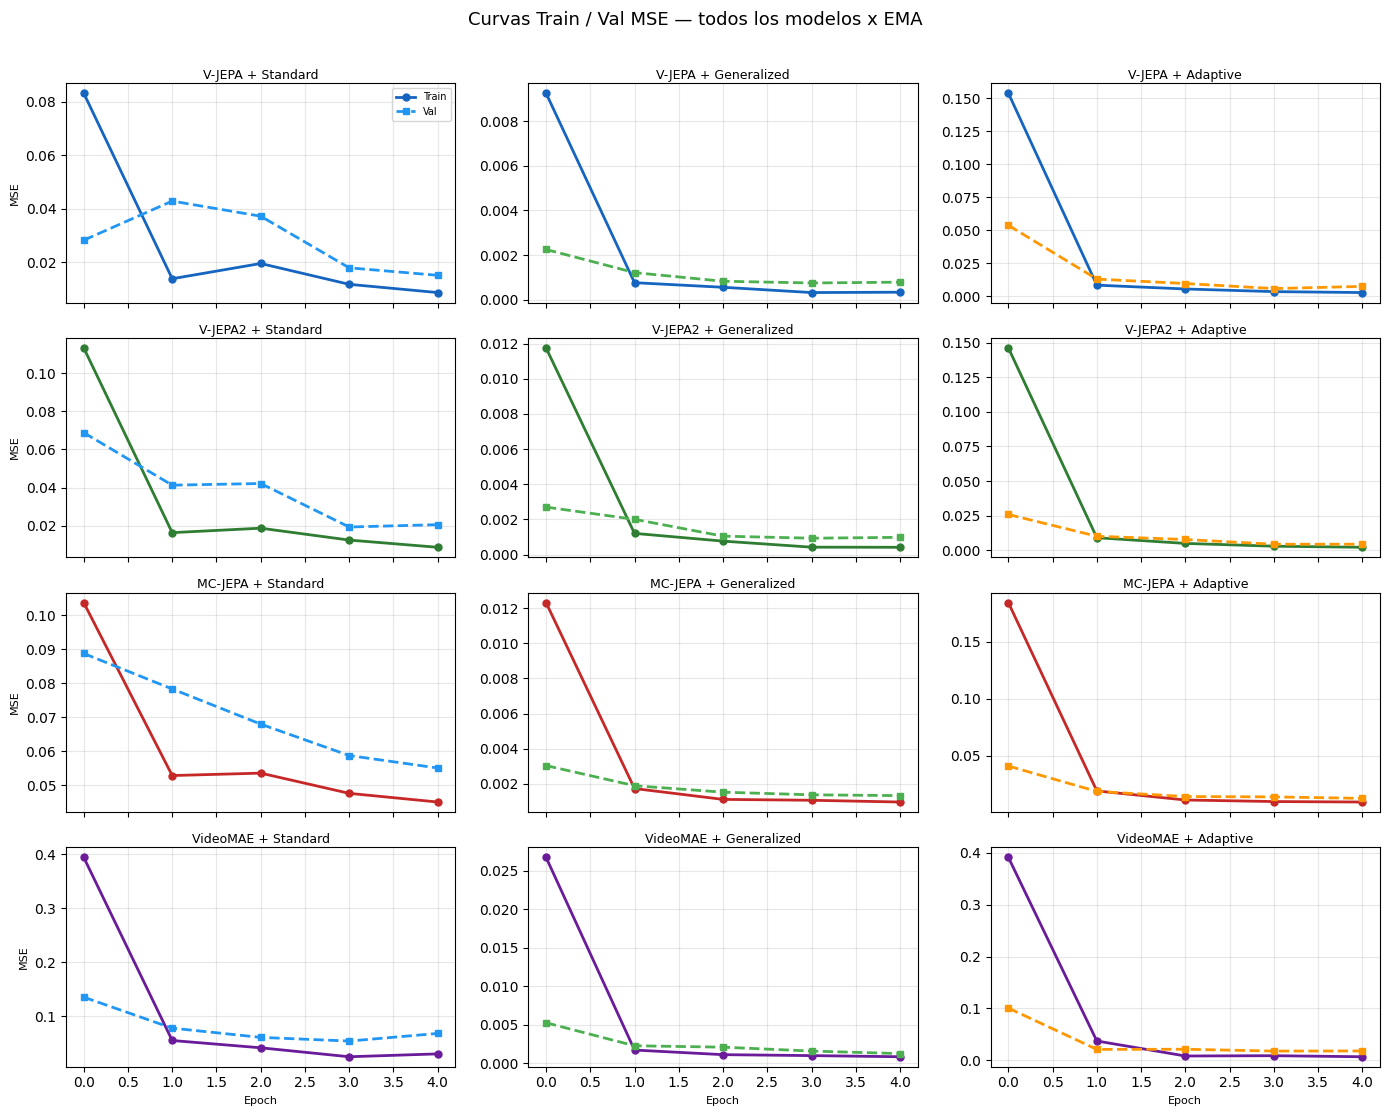

In [39]:
COLORS_EMA = {'Standard': '#2196F3', 'Generalized': '#4CAF50', 'Adaptive': '#FF9800'}
COLORS_M   = {'V-JEPA': '#1565C0', 'V-JEPA2': '#2E7D32', 'MC-JEPA': '#C62828', 'VideoMAE': '#6A1B9A'}
m_colors   = list(COLORS_M.values())

fig, axes = plt.subplots(len(MODEL_NAMES), len(EMA_NAMES), figsize=(14, 11), sharex=True)
fig.suptitle('Curvas Train / Val MSE — todos los modelos x EMA', fontsize=13, y=1.01)

for i, m_name in enumerate(MODEL_NAMES):
    for j, e_name in enumerate(EMA_NAMES):
        ax  = axes[i][j]
        sub = main[(main['model']==m_name) & (main['ema']==e_name)]
        if not sub.empty:
            ax.plot(sub['epoch'], sub['train_loss'], 'o-', lw=2, ms=5,
                    color=COLORS_M[m_name], label='Train')
            ax.plot(sub['epoch'], sub['val_loss'],   's--', lw=2, ms=5,
                    color=COLORS_EMA[e_name], label='Val')
        ax.set_title(f'{m_name} + {e_name}', fontsize=9, pad=3)
        ax.grid(True, alpha=0.3)
        if j == 0:                  ax.set_ylabel('MSE', fontsize=8)
        if i == len(MODEL_NAMES)-1: ax.set_xlabel('Epoch', fontsize=8)
        if i == 0 and j == 0:       ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(save_dir / 'fig1_curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

### Fig 2 — Heatmap val loss final (modelo × EMA)

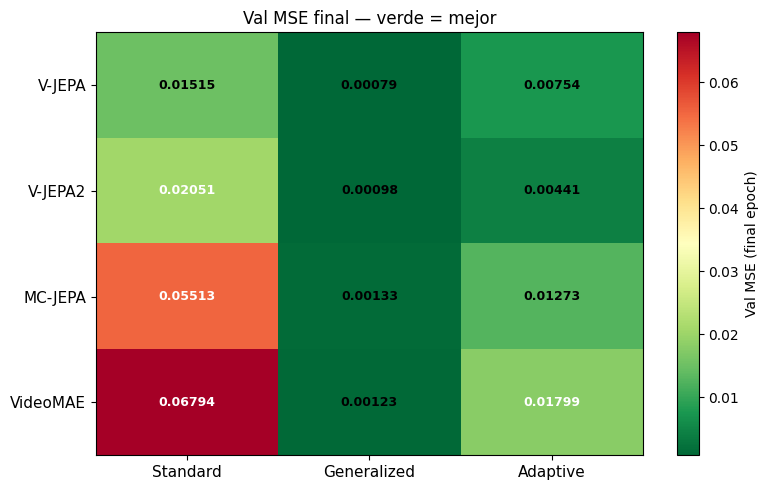

In [40]:
last_main = main.groupby(['model','ema'])['val_loss'].last().reset_index()
heat = last_main.pivot(index='model', columns='ema', values='val_loss')
heat = heat.reindex(index=MODEL_NAMES, columns=EMA_NAMES)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heat.values, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im, ax=ax, label='Val MSE (final epoch)')
ax.set_xticks(range(len(EMA_NAMES)));   ax.set_xticklabels(EMA_NAMES, fontsize=11)
ax.set_yticks(range(len(MODEL_NAMES))); ax.set_yticklabels(MODEL_NAMES, fontsize=11)
ax.set_title('Val MSE final — verde = mejor', fontsize=12)

for i in range(len(MODEL_NAMES)):
    for j in range(len(EMA_NAMES)):
        v = heat.values[i, j]
        if not np.isnan(v):
            clr = 'white' if v > np.nanmean(heat.values) else 'black'
            ax.text(j, i, f'{v:.5f}', ha='center', va='center',
                    fontsize=9, color=clr, fontweight='bold')

plt.tight_layout()
plt.savefig(save_dir / 'fig2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Fig 3 — Comparación barras (val final y mejor val)

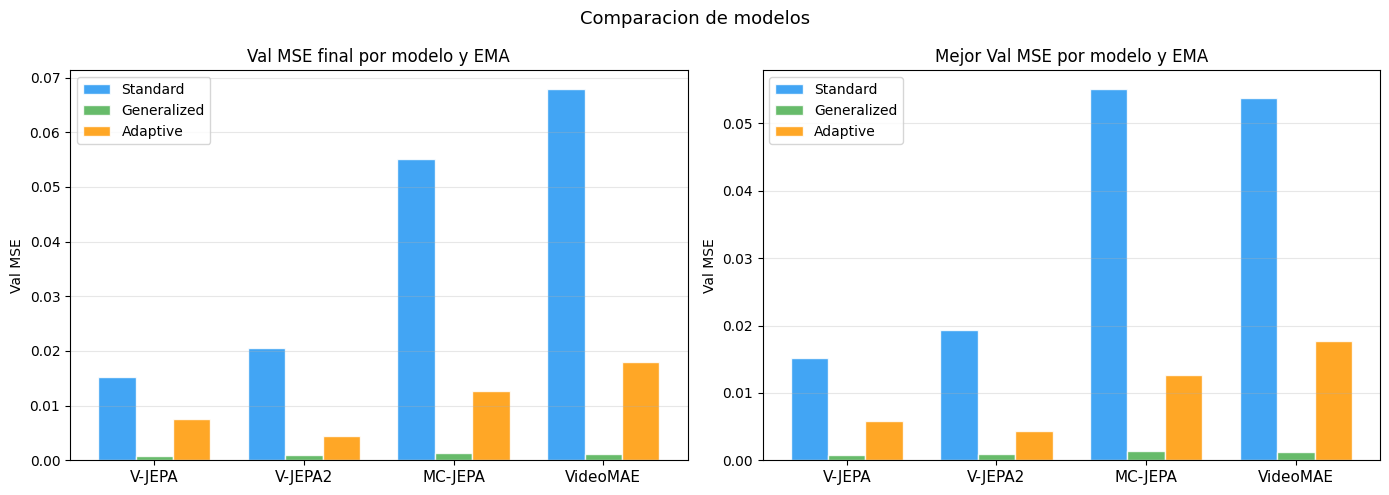

In [41]:
x     = np.arange(len(MODEL_NAMES))
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (data_fn, title) in zip(axes, [
    (lambda: last_main,
     'Val MSE final por modelo y EMA'),
    (lambda: main.groupby(['model','ema'])['val_loss'].min().reset_index(),
     'Mejor Val MSE por modelo y EMA'),
]):
    data = data_fn()
    for j, e_name in enumerate(EMA_NAMES):
        vals = [data[(data['model']==m) & (data['ema']==e_name)]['val_loss'].values
                for m in MODEL_NAMES]
        vals = [v[0] if len(v) else 0 for v in vals]
        ax.bar(x + j*width, vals, width, label=e_name,
               color=list(COLORS_EMA.values())[j], alpha=0.85, edgecolor='white')
    ax.set_xticks(x + width); ax.set_xticklabels(MODEL_NAMES, fontsize=11)
    ax.set_ylabel('Val MSE'); ax.set_title(title)
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Comparacion de modelos', fontsize=13)
plt.tight_layout()
plt.savefig(save_dir / 'fig3_comparacion_barras.png', dpi=150, bbox_inches='tight')
plt.show()

### Fig 4 — Métricas de eficiencia (tiempo · throughput · VRAM)

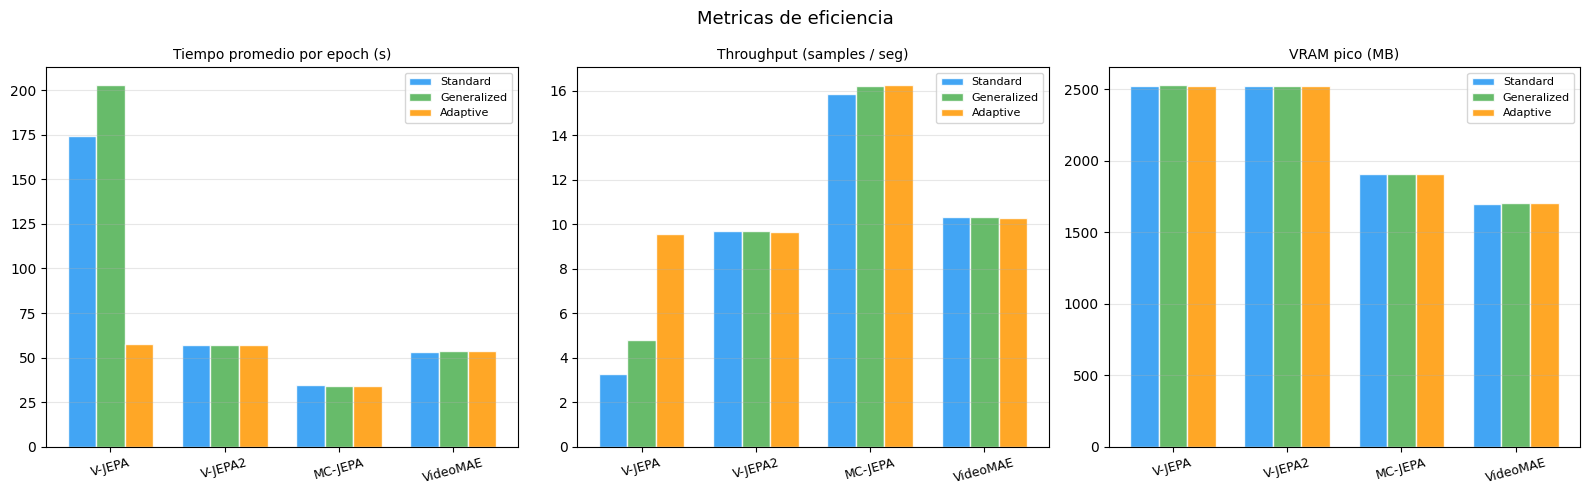

In [42]:
eff = main.groupby(['model','ema']).agg(
    time_s     = ('epoch_time_s',   'mean'),
    throughput = ('throughput_sps', 'mean'),
    vram_mb    = ('vram_peak_mb',   'max'),
).reset_index()

metrics_eff = [
    ('time_s',     'Tiempo promedio por epoch (s)'),
    ('throughput', 'Throughput (samples / seg)'),
    ('vram_mb',    'VRAM pico (MB)'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (metric, label) in zip(axes, metrics_eff):
    for j, e_name in enumerate(EMA_NAMES):
        vals = [eff[(eff['model']==m) & (eff['ema']==e_name)][metric].values
                for m in MODEL_NAMES]
        vals = [v[0] if len(v) else 0 for v in vals]
        ax.bar(x + j*width, vals, width, label=e_name,
               color=list(COLORS_EMA.values())[j], alpha=0.85, edgecolor='white')
    ax.set_xticks(x + width)
    ax.set_xticklabels(MODEL_NAMES, rotation=15, fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Metricas de eficiencia', fontsize=13)
plt.tight_layout()
plt.savefig(save_dir / 'fig4_eficiencia.png', dpi=150, bbox_inches='tight')
plt.show()

### Fig 5 — Norma de velocity EMA

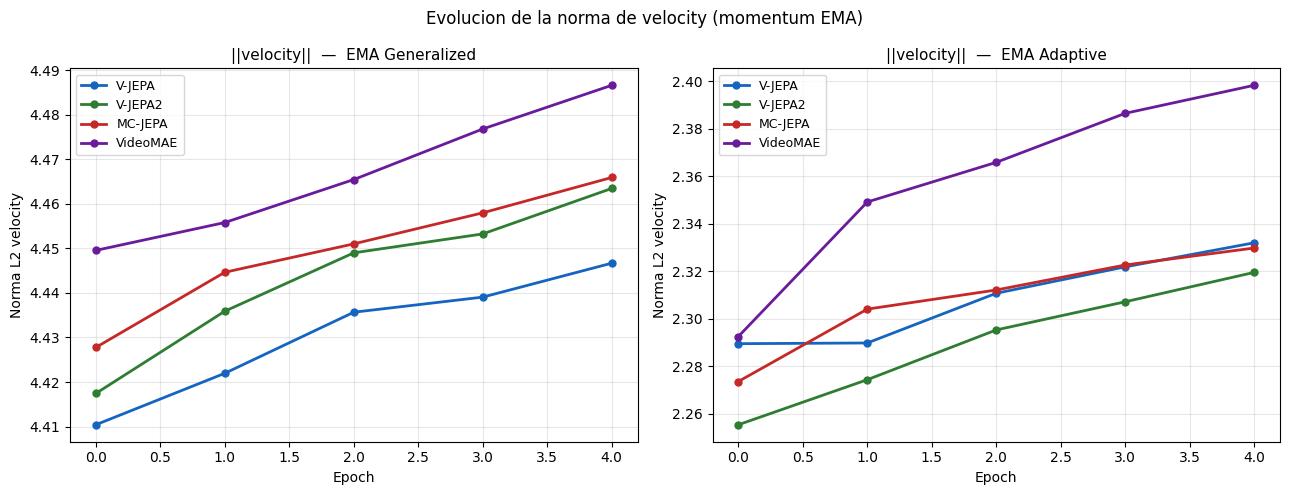

In [43]:
vel_df = main[main['ema'].isin(['Generalized', 'Adaptive'])]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, e_name in zip(axes, ['Generalized', 'Adaptive']):
    sub = vel_df[vel_df['ema'] == e_name]
    for m_name, color in zip(MODEL_NAMES, m_colors):
        ms = sub[sub['model'] == m_name]
        if not ms.empty:
            ax.plot(ms['epoch'], ms['vel_norm'], 'o-', lw=2, ms=5,
                    color=color, label=m_name)
    ax.set_title(f'||velocity||  —  EMA {e_name}', fontsize=11)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Norma L2 velocity')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('Evolucion de la norma de velocity (momentum EMA)', fontsize=12)
plt.tight_layout()
plt.savefig(save_dir / 'fig5_velocity_norm.png', dpi=150, bbox_inches='tight')
plt.show()

### Fig 6 — Cross-Validation box plots

C:\Users\52614\AppData\Local\Temp\ipykernel_31428\3720731853.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True,


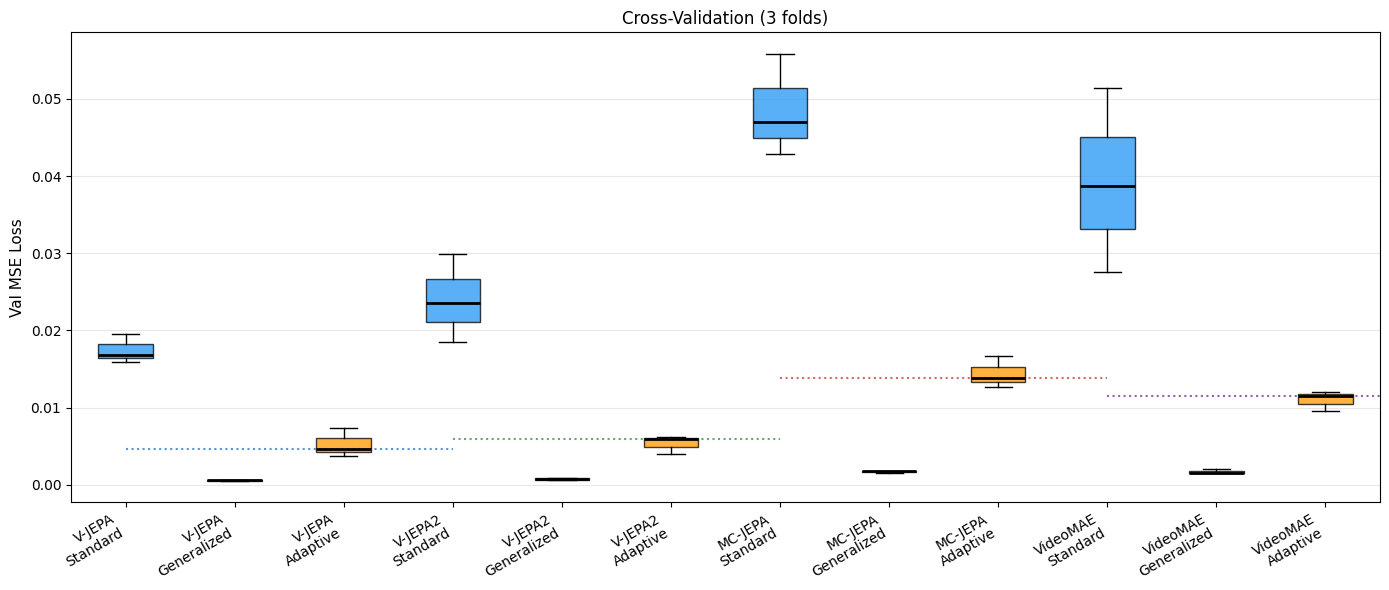

In [44]:
cv_df = df[df['fold'] > 0]

if cv_df.empty:
    print('No hay datos de CV. Corre celda 11 con cv_folds > 0.')
else:
    cv_last = cv_df.groupby(['model','ema','fold'])['val_loss'].last().reset_index()
    labels  = [f'{m}\n{e}' for m in MODEL_NAMES for e in EMA_NAMES]
    data    = []
    for m in MODEL_NAMES:
        for e in EMA_NAMES:
            v = cv_last[(cv_last['model']==m) & (cv_last['ema']==e)]['val_loss'].values
            data.append(v if len(v) else [np.nan])

    fig, ax = plt.subplots(figsize=(14, 6))
    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops={'color':'black','lw':2})
    colors_all = [list(COLORS_EMA.values())[j % 3]
                  for _ in MODEL_NAMES for j in range(len(EMA_NAMES))]
    for patch, color in zip(bp['boxes'], colors_all):
        patch.set_facecolor(color); patch.set_alpha(0.75)

    ax.set_ylabel('Val MSE Loss', fontsize=11)
    ax.set_title(f'Cross-Validation ({CONFIG["cv_folds"]} folds)', fontsize=12)
    plt.xticks(rotation=30, ha='right')
    ax.grid(True, axis='y', alpha=0.3)

    for i, m_name in enumerate(MODEL_NAMES):
        m_vals = cv_last[cv_last['model']==m_name]['val_loss'].values
        if len(m_vals):
            x_lo = (i * len(EMA_NAMES) + 0.5) / len(labels)
            x_hi = (i * len(EMA_NAMES) + len(EMA_NAMES) + 0.5) / len(labels)
            ax.axhline(np.median(m_vals), xmin=x_lo, xmax=x_hi,
                       color=m_colors[i], ls=':', lw=1.5, alpha=0.7)

    plt.tight_layout()
    plt.savefig(save_dir / 'fig6_cross_validation.png', dpi=150, bbox_inches='tight')
    plt.show()

## 14. Exportar resultados (CSV + Excel con 6 hojas)

### Estructura del Excel

| Hoja | Contenido |
|------|-----------|
| `Todos_los_registros` | Cada fila = 1 epoch de 1 experimento (incluyendo CV). ~(12×5 + 12×3×3) filas. |
| `Experimentos_principales` | Solo `fold=0`, sin CV. |
| `Resumen` | Media ± std por (modelo, EMA) sobre última epoch de cada fold. |
| `Pivot_val_loss` | Tabla cruzada modelo × EMA con el val MSE final. Fácil de leer. |
| `Eficiencia` | Val loss final/mejor, tiempo, throughput, VRAM y vel_norm por combinación. |
| `CrossValidation` | Media, std, min, max del val MSE final por fold para cada combinación. |


In [45]:
df_all = tracker.df()

# CSV completo
csv_path = save_dir / 'todas_las_metricas.csv'
df_all.to_csv(csv_path, index=False)
print(f'CSV: {csv_path}  ({len(df_all)} filas)')

# Excel con multiples hojas
xlsx_path = save_dir / 'resultados.xlsx'
with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    df_all.to_excel(writer, sheet_name='Todos_los_registros', index=False)
    main_df = df_all[df_all['fold'] == 0]
    main_df.to_excel(writer, sheet_name='Experimentos_principales', index=False)
    tracker.summary().to_excel(writer, sheet_name='Resumen')
    pivot = main_df.groupby(['model','ema'])['val_loss'].last().unstack()
    pivot = pivot.reindex(index=MODEL_NAMES, columns=EMA_NAMES)
    pivot.to_excel(writer, sheet_name='Pivot_val_loss')
    eff2 = main_df.groupby(['model','ema']).agg(
        val_loss_final   = ('val_loss',       'last'),
        val_loss_best    = ('val_loss',       'min'),
        train_loss_final = ('train_loss',     'last'),
        epoch_time_s     = ('epoch_time_s',   'mean'),
        throughput_sps   = ('throughput_sps', 'mean'),
        vram_peak_mb     = ('vram_peak_mb',   'max'),
        vel_norm_final   = ('vel_norm',       'last'),
    ).round(5)
    eff2.to_excel(writer, sheet_name='Eficiencia')
    cv_df2 = df_all[df_all['fold'] > 0]
    if not cv_df2.empty:
        cv_sum = cv_df2.groupby(['model','ema','fold'])['val_loss'].last().reset_index()
        cv_agg = cv_sum.groupby(['model','ema']).agg(
            cv_mean=('val_loss','mean'), cv_std=('val_loss','std'),
            cv_min=('val_loss','min'),   cv_max=('val_loss','max'),
        ).round(5)
        cv_agg.to_excel(writer, sheet_name='CrossValidation')

print(f'Excel guardado: {xlsx_path}')
print('Hojas: Todos_los_registros | Experimentos_principales | Resumen | Pivot_val_loss | Eficiencia | CrossValidation')
print()
print('=== TABLA FINAL ===')
print(tracker.summary().to_string())

CSV: resultados_comparacion\todas_las_metricas.csv  (168 filas)
Excel guardado: resultados_comparacion\resultados.xlsx
Hojas: Todos_los_registros | Experimentos_principales | Resumen | Pivot_val_loss | Eficiencia | CrossValidation

=== TABLA FINAL ===
                      val_loss_mean  val_loss_std  val_mse_mean  time_mean_s  throughput_mean  vram_peak_mb
model    ema                                                                                               
MC-JEPA  Adaptive           0.01400       0.00184       0.01400     89.61352          7.24084    1906.81242
         Generalized        0.00163       0.00023       0.00163     86.81788          7.36360    1906.81242
         Standard           0.05021       0.00632       0.05021    119.20195          6.49213    1904.95386
V-JEPA   Adaptive           0.00584       0.00188       0.00584     48.77148          9.88974    2525.78355
         Generalized        0.00065       0.00012       0.00065     49.01760          9.85000    252

## 15. Análisis: ¿Por qué GeneralizedEMA supera a AdaptiveEMA?

### Hipótesis principal: el gate binario

Con `k_gate=10`, la función sigmoide es **casi binaria**:

```
gate = σ(10 · (||v|| - 0.005))
```

Para `||v|| = 0.006` (apenas sobre el umbral): `gate ≈ σ(0.01) ≈ 0.502` → λ_dyn ≈ 0.30 (6× base)
Para `||v|| = 0.004` (bajo el umbral):          `gate ≈ σ(-0.01) ≈ 0.498` → λ_dyn ≈ 0.30 igualmente

La transición es tan abrupta que una diferencia de 0.002 en la norma del momentum
puede multiplicar λ por 6×. Al inicio del entrenamiento, donde el student cambia rápido
y `||v||` es naturalmente alto, **el gate está permanentemente activo** y λ_dyn se mantiene
en su máximo (0.20), haciendo que el teacher cambie demasiado rápido y pierda estabilidad.

### Las 3 variantes exploradas

| Variante | k_gate | k_lam | gate_th | v_max | Comportamiento |
|----------|--------|-------|---------|-------|----------------|
| **Ada_orig** | 10 | 5.0 | 0.005 | 0.20 | Gate binario — λ_dyn oscila entre 0.05 y 0.20 bruscamente |
| **Ada_soft** | 3 | 2.0 | 0.020 | 0.20 | Gate suave — transición gradual, umbral más alto |
| **Ada_conserv** | 5 | 1.5 | 0.015 | 0.15 | Gate moderado — λ_max limitado a 0.15 (solo 3× base) |

**Fig 7** visualiza exactamente estas curvas de gate σ y λ_dyn.
**Fig 8** muestra el ratio AdaptiveMSE / GeneralizedMSE por modelo.


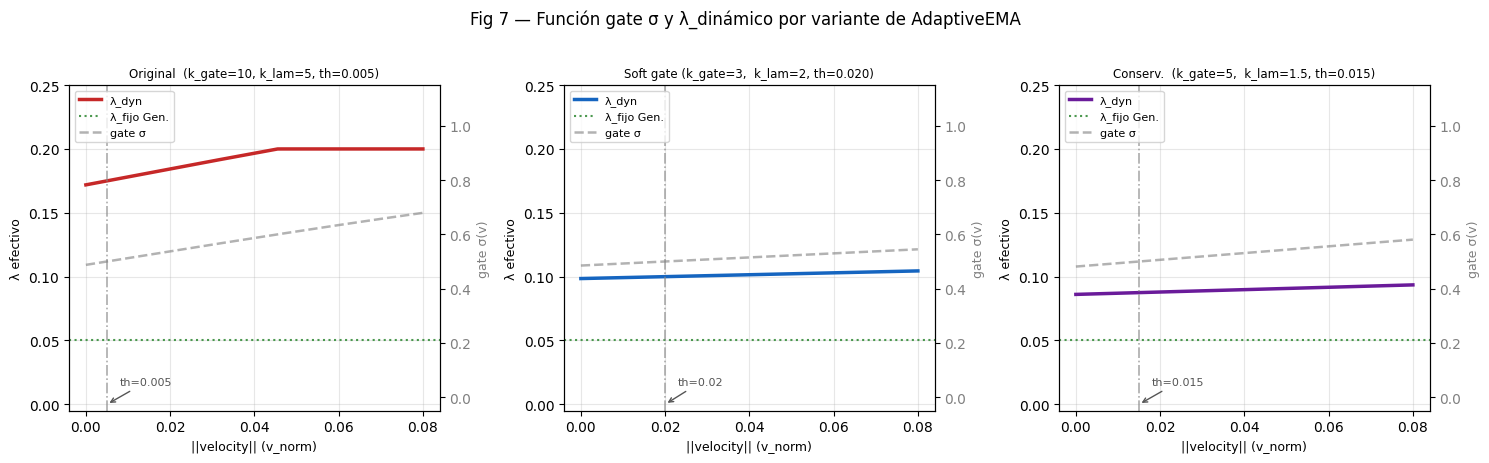

Fig 7 guardada.


In [46]:
# ── Fig 7 ── Gate function: σ + λ_dyn para 3 variantes de AdaptiveEMA ──────────

import numpy as np
import matplotlib.pyplot as plt

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))

GATE_VARIANTS = {
    'Original  (k_gate=10, k_lam=5, th=0.005)':  {
        'k_gate': 10.0, 'gate_th': 0.005, 'k_lam': 5.0,
        'lam': 0.05, 'v_max': 0.20, 'color': '#C62828'},
    'Soft gate (k_gate=3,  k_lam=2, th=0.020)':  {
        'k_gate':  3.0, 'gate_th': 0.020, 'k_lam': 2.0,
        'lam': 0.05, 'v_max': 0.20, 'color': '#1565C0'},
    'Conserv.  (k_gate=5,  k_lam=1.5, th=0.015)': {
        'k_gate':  5.0, 'gate_th': 0.015, 'k_lam': 1.5,
        'lam': 0.05, 'v_max': 0.15, 'color': '#6A1B9A'},
}

v_range = np.linspace(0, 0.08, 400)
LAM_FIXED = 0.05

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
fig.suptitle('Fig 7 — Función gate σ y λ_dinámico por variante de AdaptiveEMA',
             fontsize=12, y=1.02)

for ax, (label, p) in zip(axes, GATE_VARIANTS.items()):
    gate    = _sigmoid(p['k_gate'] * (v_range - p['gate_th']))
    lam_dyn = np.minimum(p['lam'] * (1 + p['k_lam'] * gate), p['v_max'])

    ax2 = ax.twinx()
    ax2.plot(v_range, gate, '--', lw=1.8, color='gray', alpha=0.6, label='gate σ')
    ax2.set_ylabel('gate σ(v)', color='gray', fontsize=9)
    ax2.set_ylim(-0.05, 1.15)
    ax2.tick_params(axis='y', labelcolor='gray')

    ax.plot(v_range, lam_dyn, '-',   lw=2.5, color=p['color'], label='λ_dyn')
    ax.axhline(LAM_FIXED, ls=':',  lw=1.5, color='#388E3C', alpha=0.9, label='λ_fijo Gen.')
    ax.axvline(p['gate_th'], ls='-.', lw=1.2, color='#888', alpha=0.7)

    ax.set_xlabel('||velocity|| (v_norm)', fontsize=9)
    ax.set_ylabel('λ efectivo', fontsize=9)
    ax.set_title(label, fontsize=8.5)
    ax.set_ylim(-0.005, max(0.25, p['v_max'] + 0.02))
    ax.grid(True, alpha=0.3)

    lines1, lab1 = ax.get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lab1 + lab2, fontsize=8, loc='upper left')

    ax.annotate(f"th={p['gate_th']}", xy=(p['gate_th'], 0),
                xytext=(p['gate_th'] + 0.003, p['lam'] * 0.3),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1),
                fontsize=8, color='#555')

plt.tight_layout()
save_dir_path = Path(CONFIG['save_dir'])
plt.savefig(save_dir_path / 'fig7_gate_function.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 7 guardada.')

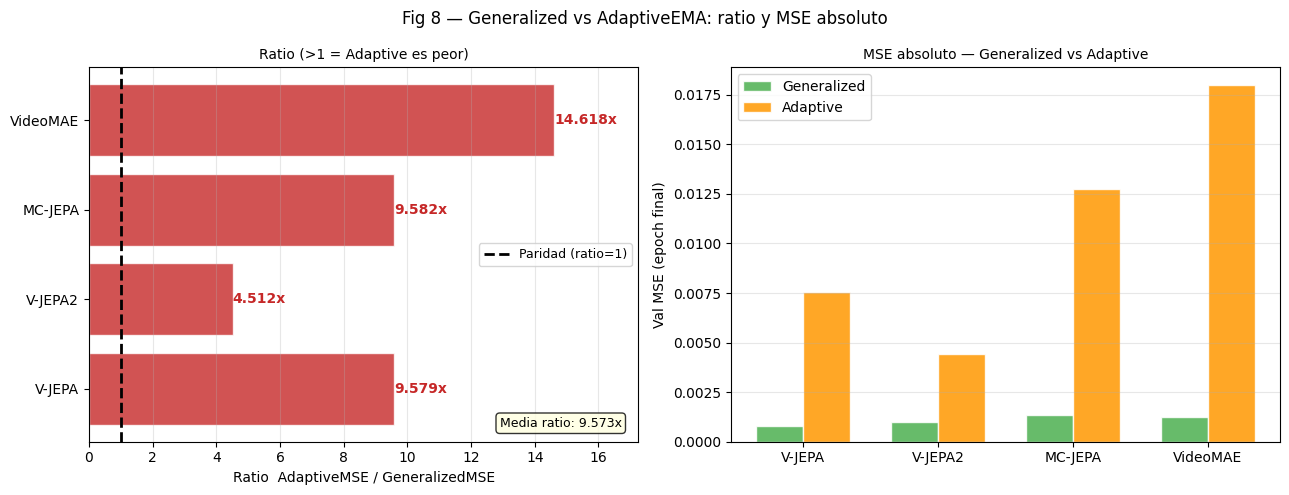

Fig 8 guardada.


In [47]:
# ── Fig 8 ── Ratio Adaptive / Generalized + MSE absoluto ────────────────────────

_last = main.groupby(['model', 'ema'])['val_loss'].last().reset_index()

gen_vals = {}
ada_vals = {}
for m in MODEL_NAMES:
    g = _last[(_last['model'] == m) & (_last['ema'] == 'Generalized')]['val_loss']
    a = _last[(_last['model'] == m) & (_last['ema'] == 'Adaptive')]['val_loss']
    gen_vals[m] = g.values[0] if len(g) else np.nan
    ada_vals[m] = a.values[0] if len(a) else np.nan

ratios_ga = [ada_vals[m] / gen_vals[m] if gen_vals[m] else np.nan for m in MODEL_NAMES]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Fig 8 — Generalized vs AdaptiveEMA: ratio y MSE absoluto', fontsize=12)

ax = axes[0]
colors_ratio = ['#C62828' if r > 1.0 else '#2E7D32' for r in ratios_ga]
bars = ax.barh(MODEL_NAMES, ratios_ga, color=colors_ratio, alpha=0.80, edgecolor='white')
ax.axvline(1.0, color='black', lw=2, ls='--', label='Paridad (ratio=1)')
for bar, r in zip(bars, ratios_ga):
    ax.text(r + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{r:.3f}x', va='center', fontsize=10, fontweight='bold',
            color='#C62828' if r > 1 else '#2E7D32')
ax.set_xlabel('Ratio  AdaptiveMSE / GeneralizedMSE', fontsize=10)
ax.set_title('Ratio (>1 = Adaptive es peor)', fontsize=10)
ax.legend(fontsize=9)
ax.set_xlim(0, max(ratios_ga) * 1.18 if any(r > 0 for r in ratios_ga) else 2)
ax.grid(True, axis='x', alpha=0.3)

ax2 = axes[1]
x2 = np.arange(len(MODEL_NAMES))
w2 = 0.35
ax2.bar(x2 - w2/2, [gen_vals[m] for m in MODEL_NAMES],
        w2, label='Generalized', color='#4CAF50', alpha=0.85, edgecolor='white')
ax2.bar(x2 + w2/2, [ada_vals[m] for m in MODEL_NAMES],
        w2, label='Adaptive',    color='#FF9800', alpha=0.85, edgecolor='white')
ax2.set_xticks(x2); ax2.set_xticklabels(MODEL_NAMES, fontsize=10)
ax2.set_ylabel('Val MSE (epoch final)', fontsize=10)
ax2.set_title('MSE absoluto — Generalized vs Adaptive', fontsize=10)
ax2.legend(fontsize=10); ax2.grid(True, axis='y', alpha=0.3)

mean_ratio = np.nanmean(ratios_ga)
axes[0].text(0.97, 0.04, f'Media ratio: {mean_ratio:.3f}x',
             transform=axes[0].transAxes, ha='right', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(save_dir_path / 'fig8_gen_vs_adaptive.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 8 guardada.')

## 16. Variantes mejoradas de AdaptiveEMA — 16 experimentos

Entrenamos los 4 modelos con 4 configuraciones EMA: Generalized (baseline) + 3 variantes Adaptive.

### Diseño de las variantes

**Ada_soft** (k_gate=3): La sigmoide con pendiente 3 tiene una transición suave de ~6 puntos
de la norma. Esto permite que λ_dyn aumente gradualmente en lugar de saltar de golpe.
El umbral alto (0.020) asegura que el gate solo se activa cuando el momentum realmente
es significativo, no por ruido inicial.

**Ada_conserv** (k_gate=5, v_max=0.15): Pendiente intermedia con un techo de λ más bajo.
`v_max=0.15` limita el multiplicador a 3× en lugar de 4×, reduciendo la agresividad máxima
de la actualización del teacher.

### ¿Qué esperamos ver?

Si la hipótesis del gate binario es correcta, `Ada_soft` debería acercarse más a
`Generalized` o incluso superarlo. `Ada_conserv` también debería mejorar respecto a `Ada_orig`.


In [48]:
# ── Sección 16 ── Tuning AdaptiveEMA: 4 modelos × 4 EMA = 16 experimentos ───────

ADAPTIVE_TUNING = [
    ('Generalized', GeneralizedEMA, {
        'alpha': 0.15, 'eta': 0.05, 'lam': 0.05, 'tau_base': 0.95}),
    ('Ada_orig', AdaptiveGeneralizedEMA, {
        'alpha': 0.15, 'eta': 0.05, 'lam': 0.05, 'tau_base': 0.95,
        'k_gate': 10.0, 'k_lam': 5.0, 'gate_th': 0.005, 'v_max': 0.20}),
    ('Ada_soft', AdaptiveGeneralizedEMA, {
        'alpha': 0.15, 'eta': 0.05, 'lam': 0.05, 'tau_base': 0.95,
        'k_gate':  3.0, 'k_lam': 2.0, 'gate_th': 0.020, 'v_max': 0.20}),
    ('Ada_conserv', AdaptiveGeneralizedEMA, {
        'alpha': 0.15, 'eta': 0.05, 'lam': 0.05, 'tau_base': 0.95,
        'k_gate':  5.0, 'k_lam': 1.5, 'gate_th': 0.015, 'v_max': 0.15}),
]

tuning_tracker = ExperimentTracker()
tuning_scaler  = torch.amp.GradScaler(enabled=(DEVICE == 'cuda'))
t_tuning = time.perf_counter()

ADA_EMA_NAMES = [e for e, _, _ in ADAPTIVE_TUNING]
print(f'Tuning: {len(MODEL_CONFIGS)} modelos × {len(ADAPTIVE_TUNING)} EMA = '
      f'{len(MODEL_CONFIGS)*len(ADAPTIVE_TUNING)} experimentos')
print()

for m_name, MClass, m_kwargs in MODEL_CONFIGS:
    for e_name, EClass, e_kwargs in ADAPTIVE_TUNING:
        print(f'  {m_name:10s} + {e_name}')
        model     = MClass(**m_kwargs).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'])
        ema_eng   = EClass(**e_kwargs)

        for epoch in range(CONFIG['epochs']):
            tr, ep_t, tps, vmb, vnorm = train_epoch(
                model, train_loader, optimizer, tuning_scaler, ema_eng)
            vl = val_epoch(model, val_loader)
            tuning_tracker.log(m_name, e_name, 0, epoch, tr, vl,
                               ep_t, tps, vmb, vnorm)
        print(f'    → val final = {vl:.5f}')

print(f'\n Tuning completado en {(time.perf_counter()-t_tuning)/60:.1f} min')

df_tuning = tuning_tracker.df()
tuning_last = df_tuning.groupby(['model', 'ema'])['val_loss'].last().reset_index()
print()
print('=== RESUMEN TUNING ===')
print(tuning_last.pivot(index='model', columns='ema', values='val_loss')
      .reindex(index=MODEL_NAMES, columns=ADA_EMA_NAMES).round(5).to_string())

Tuning: 4 modelos × 4 EMA = 16 experimentos

  V-JEPA     + Generalized
    → val final = 0.00090
  V-JEPA     + Ada_orig
    → val final = 0.00652
  V-JEPA     + Ada_soft
    → val final = 0.00489
  V-JEPA     + Ada_conserv
    → val final = 0.00312
  V-JEPA2    + Generalized
    → val final = 0.00111
  V-JEPA2    + Ada_orig
    → val final = 0.00502
  V-JEPA2    + Ada_soft
    → val final = 0.00294
  V-JEPA2    + Ada_conserv
    → val final = 0.00298
  MC-JEPA    + Generalized
    → val final = 0.00143
  MC-JEPA    + Ada_orig
    → val final = 0.00830
  MC-JEPA    + Ada_soft
    → val final = 0.00932
  MC-JEPA    + Ada_conserv
    → val final = 0.00781
  VideoMAE   + Generalized
    → val final = 0.00129
  VideoMAE   + Ada_orig
    → val final = 0.01154
  VideoMAE   + Ada_soft
    → val final = 0.00811
  VideoMAE   + Ada_conserv
    → val final = 0.01342

 Tuning completado en 107.9 min

=== RESUMEN TUNING ===
ema       Generalized  Ada_orig  Ada_soft  Ada_conserv
model              

## 17. Fig 9 — Comparación de variantes de Adaptive vs Generalized

### Cómo leer la Fig 9

**Subplot izquierdo (MSE absoluto)**: 4 barras agrupadas por modelo, una por cada variante EMA.
Permite ver si alguna variante Adaptive alcanza o supera a Generalized en términos absolutos.

**Subplot derecho (ratio vs Generalized)**: el ratio `Ada_val / Gen_val`.
- Ratio > 1 → la variante Adaptive es peor que Generalized.
- Ratio < 1 → la variante Adaptive es **mejor** que Generalized (marca ✓ en verde).
- La línea verde punteada en 1.0 es el baseline de Generalized.

Si `Ada_soft` o `Ada_conserv` tienen ratio cercano a 1 o menor, confirma que suavizar
el gate es la corrección correcta.


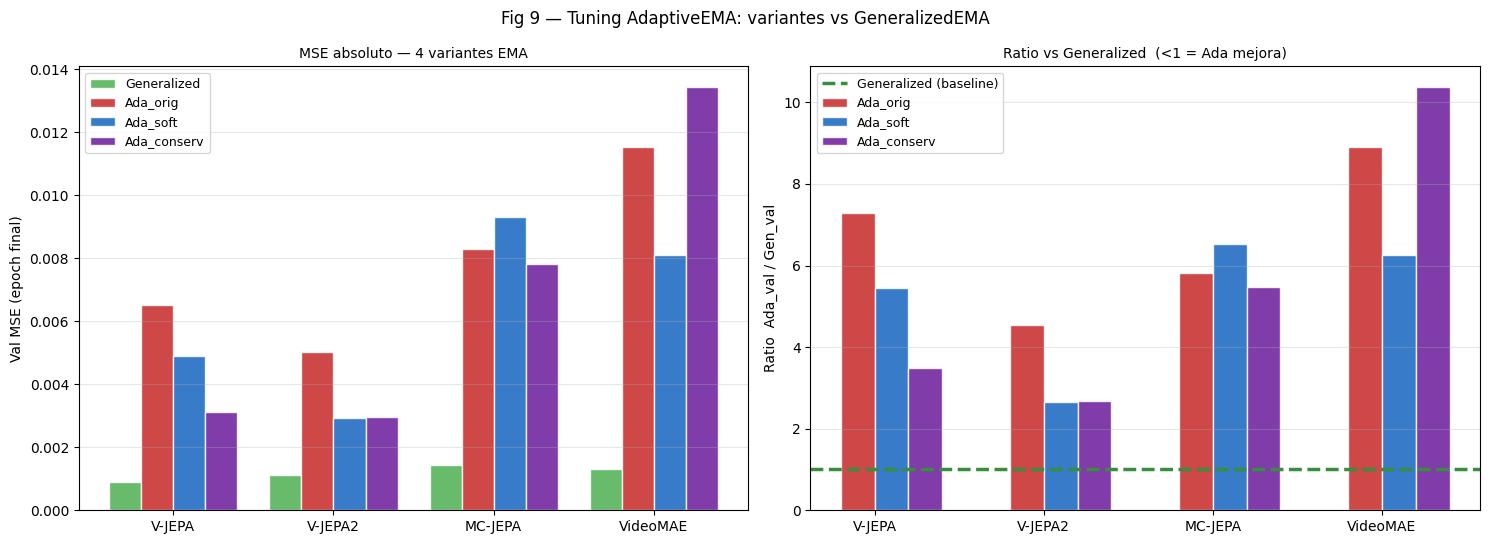

Fig 9 guardada.


In [49]:
# ── Fig 9 ── Tuning: MSE absoluto + ratio vs Generalized ────────────────────────

df_tuning  = tuning_tracker.df()
tun_last   = df_tuning.groupby(['model', 'ema'])['val_loss'].last().reset_index()

gen_base = {}
for m in MODEL_NAMES:
    g = tun_last[(tun_last['model'] == m) & (tun_last['ema'] == 'Generalized')]['val_loss']
    gen_base[m] = g.values[0] if len(g) else np.nan

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Fig 9 — Tuning AdaptiveEMA: variantes vs GeneralizedEMA', fontsize=12)

ADA_ONLY    = ['Ada_orig', 'Ada_soft', 'Ada_conserv']
ADA_COLORS  = {'Generalized': '#4CAF50', 'Ada_orig': '#C62828',
               'Ada_soft': '#1565C0', 'Ada_conserv': '#6A1B9A'}
x3    = np.arange(len(MODEL_NAMES))
width = 0.20
offsets = np.linspace(-1.5*width, 1.5*width, 4)

ax = axes[0]
for k, (e_name, off) in enumerate(zip(ADA_EMA_NAMES, offsets)):
    vals = [tun_last[(tun_last['model']==m) & (tun_last['ema']==e_name)]['val_loss'].values
            for m in MODEL_NAMES]
    vals = [v[0] if len(v) else np.nan for v in vals]
    ax.bar(x3 + off, vals, width, label=e_name,
           color=ADA_COLORS[e_name], alpha=0.85, edgecolor='white')
ax.set_xticks(x3); ax.set_xticklabels(MODEL_NAMES, fontsize=10)
ax.set_ylabel('Val MSE (epoch final)', fontsize=10)
ax.set_title('MSE absoluto — 4 variantes EMA', fontsize=10)
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)

ax2 = axes[1]
for k, (e_name, off) in enumerate(zip(ADA_ONLY, offsets[1:])):
    ratios = []
    for m in MODEL_NAMES:
        v = tun_last[(tun_last['model']==m) & (tun_last['ema']==e_name)]['val_loss']
        val = v.values[0] if len(v) else np.nan
        ratios.append(val / gen_base[m] if gen_base[m] else np.nan)
    ax2.bar(x3 + off, ratios, width, label=e_name,
            color=ADA_COLORS[e_name], alpha=0.85, edgecolor='white')

ax2.axhline(1.0, color='#388E3C', lw=2.5, ls='--', label='Generalized (baseline)')
ax2.set_xticks(x3); ax2.set_xticklabels(MODEL_NAMES, fontsize=10)
ax2.set_ylabel('Ratio  Ada_val / Gen_val', fontsize=10)
ax2.set_title('Ratio vs Generalized  (<1 = Ada mejora)', fontsize=10)
ax2.legend(fontsize=9); ax2.grid(True, axis='y', alpha=0.3)

for k, e_name in enumerate(ADA_ONLY):
    for i, m in enumerate(MODEL_NAMES):
        v = tun_last[(tun_last['model']==m) & (tun_last['ema']==e_name)]['val_loss']
        if len(v) and gen_base[m]:
            r = v.values[0] / gen_base[m]
            if r < 0.98:
                ax2.annotate('✓', xy=(x3[i] + offsets[k+1], r),
                             xytext=(0, 6), textcoords='offset points',
                             ha='center', fontsize=9, color='#2E7D32', fontweight='bold')

plt.tight_layout()
plt.savefig(save_dir_path / 'fig9_tuning_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Fig 9 guardada.')

In [50]:
# ── Export actualizado: agrega tuning al CSV y Excel ────────────────────────────

df_tuning = tuning_tracker.df()

csv_tuning = save_dir / 'tuning_adaptiveema.csv'
df_tuning.to_csv(csv_tuning, index=False)
print(f'CSV tuning: {csv_tuning}  ({len(df_tuning)} filas)')

xlsx_path = save_dir / 'resultados.xlsx'
try:
    from openpyxl import load_workbook
    book = load_workbook(xlsx_path)
    with pd.ExcelWriter(xlsx_path, engine='openpyxl', mode='a',
                        if_sheet_exists='replace') as writer:
        writer.book = book
        df_tuning.to_excel(writer, sheet_name='Tuning_AdaptiveEMA', index=False)
        tun_pivot = (df_tuning.groupby(['model','ema'])['val_loss']
                     .last().unstack()
                     .reindex(index=MODEL_NAMES, columns=ADA_EMA_NAMES))
        tun_pivot.round(5).to_excel(writer, sheet_name='Tuning_Pivot')
    print(f'Excel actualizado con hojas Tuning_AdaptiveEMA y Tuning_Pivot')
except Exception as e:
    print(f'Advertencia ({e}), reescribiendo Excel...')
    with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
        tracker.df().to_excel(writer, sheet_name='Todos_los_registros', index=False)
        df_tuning.to_excel(writer, sheet_name='Tuning_AdaptiveEMA', index=False)
        tun_pivot = (df_tuning.groupby(['model','ema'])['val_loss']
                     .last().unstack()
                     .reindex(index=MODEL_NAMES, columns=ADA_EMA_NAMES))
        tun_pivot.round(5).to_excel(writer, sheet_name='Tuning_Pivot')

print()
print('=== TABLA FINAL TUNING ===')
tun_summary = (df_tuning.groupby(['model','ema'])['val_loss']
               .last().unstack()
               .reindex(index=MODEL_NAMES, columns=ADA_EMA_NAMES))
print(tun_summary.round(5).to_string())
print()
print('Mejor variante por modelo:')
for m in MODEL_NAMES:
    row = tun_summary.loc[m]
    best_e = row.idxmin()
    print(f'  {m:10s}  →  {best_e}  (val MSE = {row[best_e]:.5f})')

CSV tuning: resultados_comparacion\tuning_adaptiveema.csv  (80 filas)
Advertencia (can't set attribute 'book'), reescribiendo Excel...

=== TABLA FINAL TUNING ===
ema       Generalized  Ada_orig  Ada_soft  Ada_conserv
model                                                 
V-JEPA        0.00090   0.00652   0.00489      0.00312
V-JEPA2       0.00111   0.00502   0.00294      0.00298
MC-JEPA       0.00143   0.00830   0.00932      0.00781
VideoMAE      0.00129   0.01154   0.00811      0.01342

Mejor variante por modelo:
  V-JEPA      →  Generalized  (val MSE = 0.00090)
  V-JEPA2     →  Generalized  (val MSE = 0.00111)
  MC-JEPA     →  Generalized  (val MSE = 0.00143)
  VideoMAE    →  Generalized  (val MSE = 0.00129)
